# Plot environmental data for 2022 growth experiment

Author: **Niels J. de Winter** (*n.j.de.winter@vu.nl*)<br>
Assistant Professor Vrije Universiteit Amsterdam

## Load packages

In [38]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

## Load temperature and salinity data

In [39]:
# Load the environmental data
env_data_path = "min60_2022.csv"
env_df = pd.read_csv(env_data_path, sep=None, engine='python')

# Remove spaces from column names
env_df.columns = env_df.columns.str.replace(' ', '', regex=True)

# Parse the date column (TM)
env_df['TM'] = pd.to_datetime(env_df['TM'], format='%Y%m%d%H%M%S', errors='coerce')

# Convert numeric columns to appropriate types
numeric_columns = ['T', 'T_std', 'T_N', 'T_max', 'T_min', 'S', 'S_std', 'S_N', 'S_max', 'S_min',]
for col in numeric_columns:
    env_df[col] = pd.to_numeric(env_df[col], errors='coerce')

print(env_df.head())

                   TM           ET      T  T_std  T_N  T_max  T_min  T_flag  \
0 2022-01-01 01:00:00  44562.04167  6.562  0.105  6.0  6.677  6.438     1.0   
1 2022-01-01 02:00:00  44562.08333  6.676  0.059  6.0  6.805  6.646     1.0   
2 2022-01-01 03:00:00  44562.12500  6.982  0.050  6.0  7.031  6.906     1.0   
3 2022-01-01 04:00:00  44562.16667  7.008  0.073  6.0  7.183  6.991     1.0   
4 2022-01-01 05:00:00  44562.20833  7.141  0.093  6.0  7.244  7.024     1.0   

        S  S_std  S_N   S_max   S_min  S_flag  
0  28.145  0.288  6.0  28.435  27.795     1.0  
1  28.465  0.224  6.0  29.005  28.415     1.0  
2  29.395  0.121  6.0  29.505  29.225     1.0  
3  29.385  0.208  6.0  29.875  29.335     1.0  
4  29.670  0.305  6.0  30.065  29.315     1.0  


## Load high tide series data

In [40]:
# Load the data from high tide measurements
HW_data_path = "HWseries_2022.csv"
HW_df = pd.read_csv(HW_data_path, sep=None, engine='python')

# Convert the date column (Timestamp [UTC]) to datetime format
HW_df['TM'] = pd.to_datetime(HW_df['Timestamp [UTC]'], format='%d/%m/%Y %H:%M', errors='coerce')
print(HW_df.head())

  SampleID   Timestamp [UTC]    T     S SecchiDepth      TN     TP    PO4  \
0   HW2201  04/01/2022 09:06  8.0  30.8         0.8  40.756  0.980  0.811   
1   HW2202  12/01/2022 13:04  6.0  26.6         1.2  53.431  0.794  0.628   
2   HW2203  02/02/2022 09:05  6.6  28.0         0.9  45.559  0.638  0.448   
3   HW2204  24/02/2022 10:27  7.0  28.7         0.7  61.718  0.789  0.642   
4   HW2205  10/03/2022 10:04  6.1  24.1         0.7  91.492  0.474  0.280   

      NO3    NO2    NH4     DON    DOP     Si     DIC    TSM     Chl  \
0  24.253  1.078  6.940   8.485  0.169  18.01  2319.5  24.20   1.715   
1  29.230  1.560  8.917  13.724  0.166  21.57  2371.0  13.40   1.651   
2  26.868  1.111  5.724  11.856  0.190  16.71  2335.8  17.65   2.087   
3  47.019  0.950  4.772   8.977  0.147  27.46  2301.2  39.60   1.451   
4  67.368  0.984  4.682  18.458  0.194  34.73  2396.9  36.30  12.143   

                   TM  
0 2022-01-04 09:06:00  
1 2022-01-12 13:04:00  
2 2022-02-02 09:05:00  
3 2022-0

## Read all cleanalyze data with growth rates (to prevent having to calculate them again)

In [ ]:
# folder_path = "TE_data_with_growth_rates"
# csv_files = [f for f in os.listdir(folder_path) if f.endswith('.csv')] # List all CSV files in the folder
# dataframes = {}

# for file in csv_files:
#     file_path = os.path.join(folder_path, file)
#     df = pd.read_csv(file_path)
#     dataframes[file] = df

# # Print the first few rows of each DataFrame
# for file, df in dataframes.items():
#     print(f"Data from {file}:")
#     print(df.head(), "\n")  # Display the first few rows of each DataFrame
#     print(f"Shape: {df.shape}\n")  # Print the shape of the DataFrame
#     print(f"Columns: {df.columns.tolist()}\n")  # Print the column names
#     print("-" * 40)  # Separator for clarity

Data from B255_int_peakid.csv:
      depth  proxy_filtered      time         Xpos         Ypos         Ca43  \
0  0.445779        0.013676  62.33211  30944.10620  80703.27530  6301.588000   
1  0.891558        0.000000  62.44125  30944.46978  80703.01737  5301.123838   
2  1.337336        0.019326  62.55040  30944.83337  80702.75945  4600.846556   
3  1.783115        0.037763  62.65955  30945.19695  80702.50152  5751.322804   
4  2.228894        0.013795  62.76871  30945.56053  80702.24359  6251.562891   

    23Na/43Ca  25Mg/43Ca  43Ca/43Ca  55Mn/43Ca  ...  \
0  199.059248   1.253571       1000   0.306491  ...   
1  235.482235   3.406310       1000   0.347474  ...   
2  284.331679   1.771388       1000   0.380053  ...   
3  221.307763   3.115197       1000   0.348871  ...   
4  205.558351   1.264443       1000   0.242893  ...   

   interval_growth_rate_peakID_3  interval_growth_rate_centered_peakID_3  \
0                      20.329382                               20.329382   
1    

### Plot total growth and growth rate vs time considering peak centers as boundaries

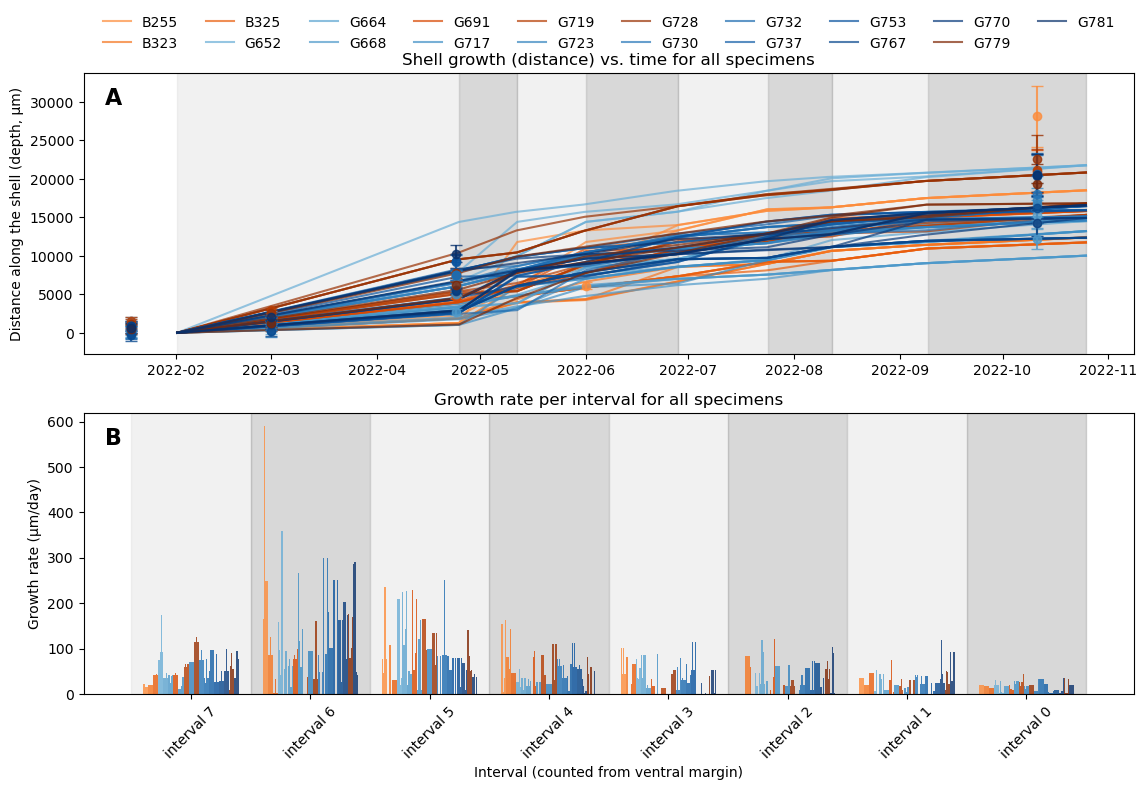

In [ ]:
# # Create a figure with two subplots: ax1 for shell growth (date x-axis), ax2 for growth rates (interval x-axis)
# fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=False, gridspec_kw={'height_ratios': [1, 1]})

# # Prepare color maps for subtidal and intertidal specimens
# subtidal_files = [f for f in dataframes if 'sub' in f.lower()]
# intertidal_files = [f for f in dataframes if 'int' in f.lower()]
# subtidal_colors = cm.Blues(np.linspace(0.5, 1, len(subtidal_files)))
# intertidal_colors = cm.Oranges(np.linspace(0.5, 1, len(intertidal_files)))

# # Define labels as the list of specimen_peakID names combined with peakID columns
# labels = list(growth_intervals.keys())

# sub_idx = 0
# inter_idx = 0

# # For bar chart
# bar_intervals = []
# bar_rates = []
# bar_colors = []
# bar_specimens = []

# # Line plot: shell growth vs. date
# for file, df in dataframes.items():
#     # Loop through each peak identification option
#     for timing_col in ['timing_1', 'timing_2', 'timing_3', 'timing_4']:
#         # Find column name according to peak label
#         if timing_col == 'timing_1':
#             timing_centered_col = 'timing_1_centered'
#         elif timing_col == 'timing_2':
#             timing_centered_col = 'timing_2_centered'
#         elif timing_col == 'timing_3':
#             timing_centered_col = 'timing_3_centered'
#         elif timing_col == 'timing_4':
#             timing_centered_col = 'timing_4_centered'
#         if 'depth' in df.columns and timing_col in df.columns:
#             df_plot = df.copy()
#             df_plot[timing_col] = pd.to_datetime(df_plot[timing_col])
#             df_plot[timing_centered_col] = pd.to_datetime(df_plot[timing_centered_col])
#             df_plot['depth'] = df_plot['depth'].max() - df_plot['depth']
#             if 'sub' in file.lower():
#                 color = subtidal_colors[sub_idx]
#             elif 'int' in file.lower():
#                 color = intertidal_colors[inter_idx]
#             ax1.plot(df_plot[timing_centered_col], df_plot['depth'], label=file, alpha=0.7, color=color) # Plotting depth against timing_info_centered
#     if 'sub' in file.lower():
#         sub_idx += 1
#     elif 'int' in file.lower():
#         inter_idx += 1
#     # --- Add caliper long data (distance_mm_individual) with CI to the line plots ---
#     for specimen_name in caliper_long['specimen'].unique():
#         # Find files containing this specimen name
#         matching_files = [f for f in dataframes if specimen_name in f]
#         if file in matching_files:
#             group = caliper_long[caliper_long['specimen'] == specimen_name]
#             # Determine color and label for this specimen (same as line plot)
#             if 'sub' in file.lower():
#                 color = subtidal_colors[subtidal_files.index(file)]
#             elif 'int' in file.lower():
#                 color = intertidal_colors[intertidal_files.index(file)]
#             label = file  # Use the same label as in the line plot
#             # Plot on ax1 (date x-axis, centered if available)
#             ax1.errorbar(
#                 group['date'], group['distance_mm_individual'] * 1000, # Convert to micrometers
#                 yerr=group['distance_mm_ci_individual'] * 1000 if 'distance_mm_ci_individual' in group.columns else None,
#                 fmt='o', capsize=4, label=label,
#                 color=color, alpha=0.8, zorder=10
#             )

#             # Bar chart: growth rate per interval
#             growths = growth_intervals.get(file + "_" + peakID_col, {})
#             for interval_label, stats in growths.items():
#                 if stats['growth_rate'] is not None and not np.isnan(stats['growth_rate']):
#                     bar_intervals.append(int(interval_label.split()[-1]))
#                     bar_rates.append(stats['growth_rate'])
#                     bar_colors.append(color)
#                     bar_specimens.append(file)

# # --- Prepare for grouped bar plot ---
# unique_intervals = [f'interval {i}' for i in interval_numbers][::-1]
# unique_specimens_peakIDs = list(labels)
# n_intervals = len(unique_intervals)
# n_specimens_peakID = len(unique_specimens_peakIDs) # of specimen_peakID combinations
# n_specimens = len(dataframes)  # of specimens

# # Build a matrix of growth rates: rows=intervals, cols=specimens
# growth_rate_matrix_centered = np.full((n_intervals, n_specimens_peakID), np.nan)
# bar_colors_matrix = np.empty((n_intervals, n_specimens_peakID), dtype=object)

# for s_idx, specimen_peakID in enumerate(unique_specimens_peakIDs):
#     specimen = specimen_peakID.rsplit("_", 2)[0]  # Extract specimen name
#     growths = growth_intervals.get(specimen_peakID, {})
#     for i_idx, interval in enumerate(unique_intervals):
#         stats = growths.get(interval, None)
#         if stats and stats['growth_rate'] is not None and not np.isnan(stats['growth_rate']):
#             growth_rate_matrix_centered[i_idx, s_idx] = stats['growth_rate_centered']
#             # Assign color as before
#             if 'sub' in specimen_peakID.lower():
#                 color = subtidal_colors[subtidal_files.index(specimen)]
#             elif 'int' in specimen_peakID.lower():
#                 color = intertidal_colors[intertidal_files.index(specimen)]
#             else:
#                 color = 'green'
#             bar_colors_matrix[i_idx, s_idx] = color
#         else:
#             bar_colors_matrix[i_idx, s_idx] = 'grey'

# # Flip order of intervals for plotting (interval 0 at the bottom)
# growth_rate_matrix_centered = growth_rate_matrix_centered[::-1, :]
# bar_colors_matrix = bar_colors_matrix[::-1, :]

# bar_width = 0.8 / n_specimens_peakID  # Make bars for each interval adjacent

# # --- Plot grouped bars ---
# for s_idx, specimen_peakID in enumerate(unique_specimens_peakIDs):
#     x_positions = np.arange(n_intervals) + s_idx * bar_width - 0.4 + bar_width/2
#     ax2.bar(
#         x_positions,
#         growth_rate_matrix_centered[:, s_idx],
#         width=bar_width,
#         color=bar_colors_matrix[:, s_idx],
#         alpha=0.8,
#         label=specimen_peakID if s_idx == 0 else None  # Only label once for legend
#     )

# # Set x-ticks for intervals
# ax2.set_xticks(np.arange(n_intervals))
# # # Add mean dates of intervals to x-tick labels
# # interval_labels_with_dates = []
# # for interval in unique_intervals:
# #     start = growth_intervals_df[growth_intervals_df['Interval'] == interval]['start_date'].dropna()
# #     end = growth_intervals_df[growth_intervals_df['Interval'] == interval]['end_date'].dropna()
# #     if not start.empty and not end.empty:
# #         mean_date = pd.to_datetime(start).mean() + (pd.to_datetime(end).mean() - pd.to_datetime(start).mean()) / 2
# #         label = f"{interval}\n{mean_date.strftime('%Y-%m-%d')}"
# #     else:
# #         label = interval
# #     interval_labels_with_dates.append(label)

# ax2.set_xticklabels(unique_intervals, rotation=45)
# ax2.set_xlabel('Interval (counted from ventral margin)')
# ax2.set_ylabel('Growth rate (μm/day)')
# ax2.set_title('Growth rate per interval for all specimens')

# # Format and legend for the shell growth plot
# # Add shaded background boxes to delineate intervals on both plots
# for i, interval in enumerate(unique_intervals):
#     # Get start and end dates for the interval
#     start = growth_intervals_df[growth_intervals_df['Interval'] == interval]['start_date'].dropna()
#     end = growth_intervals_df[growth_intervals_df['Interval'] == interval]['end_date'].dropna()
#     if not start.empty and not end.empty:
#         # Shade on ax1 (date x-axis)
#         ax1.axvspan(start.iloc[0], end.iloc[0], color='grey' if i % 2 == 0 else 'lightgrey', alpha=0.3, zorder=0)
#         # Shade on ax2 (interval x-axis)
#         ax2.axvspan(i - 0.5, i + 0.5, color='lightgrey' if i % 2 == 0 else 'grey', alpha=0.3, zorder=0)
# ax1.set_ylabel('Distance along the shell (depth, μm)')
# ax1.set_title('Shell growth (distance) vs. time for all specimens')
# # Merge legend elements with the same name
# handles, labels = ax1.get_legend_handles_labels()
# labels = [label.split("_")[0] for label in labels]  # Simplify labels to specimen names
# unique = OrderedDict()
# for h, l in zip(handles, labels):
#     if l not in unique:
#         unique[l] = h
# ax1.legend(unique.values(), unique.keys(), loc='upper center', bbox_to_anchor=(0.5, 1.25), ncol=10, frameon=False)

# # Add labels to subplots
# ax1.annotate("A", xy=(0.02, 0.95), xycoords='axes fraction', fontsize=16, fontweight='bold', va='top')
# ax2.annotate("B", xy=(0.02, 0.95), xycoords='axes fraction', fontsize=16, fontweight='bold', va='top')
# plt.tight_layout()
# plt.show()

## Create plot of temperature, salinity and Chlorophyl-A against time over the 2022 growth experiment

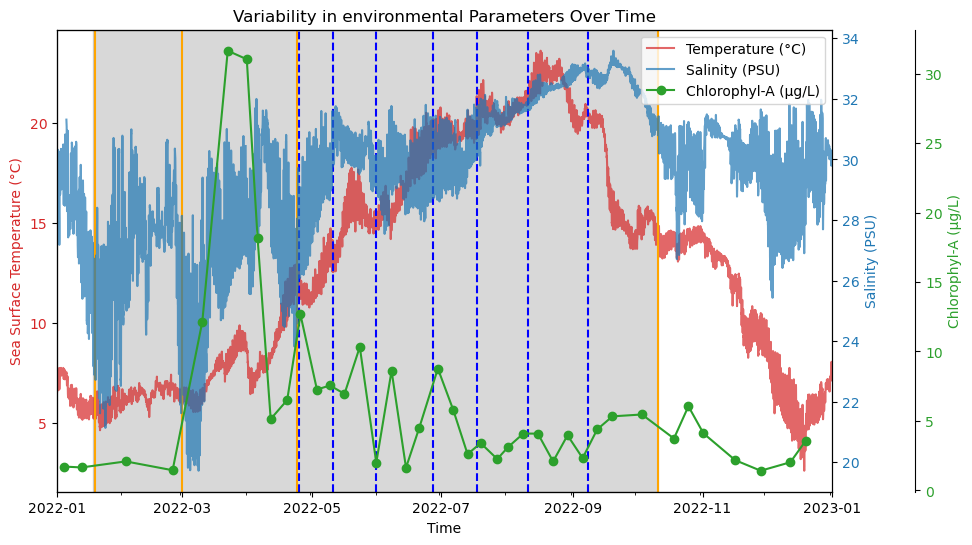

In [51]:
# Create plot of temperature, salinity and Chlorophyl-A against time over the 2022 growth experiment
# Set up the figure and axes
fig, ax1 = plt.subplots(figsize=(10, 6))

# Plot temperature on the primary y-axis
ax1.plot(env_df['TM'], env_df['T'], color='tab:red', label='Temperature (°C)', alpha=0.7)
ax1.set_xlabel('Time')
ax1.set_ylabel('Sea Surface Temperature (°C)', color='tab:red')
ax1.tick_params(axis='y', labelcolor='tab:red')

# Create a secondary y-axis for salinity
ax2 = ax1.twinx()
ax2.plot(env_df['TM'], env_df['S'], color='tab:blue', label='Salinity (PSU)', alpha=0.7)
ax2.set_ylabel('Salinity (PSU)', color='tab:blue')
ax2.tick_params(axis='y', labelcolor='tab:blue')

# Create a secondary y-axis for Chlorophyl-A
ax3 = ax1.twinx()
ax3.plot(HW_df['TM'], HW_df['Chl'], color='tab:green', label='Chlorophyl-A (µg/L)', marker='o')
ax3.set_ylabel('Chlorophyl-A (µg/L)', color='tab:green')
ax3.tick_params(axis='y', labelcolor='tab:green')
ax3.spines['right'].set_position(('outward', 60))  # Move the third y-axis outwards

# Format plot
fig.legend(loc='upper right', bbox_to_anchor=(0.9, 0.88))
ax1.set_xlim(pd.to_datetime(['20220101000000', '20230101000000'], format='%Y%m%d%H%M%S', errors='coerce'))
ax1.set_xticks(pd.date_range(start='2022-01-01', end='2023-01-01', freq='ME'), minor=True)
# ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b'))  # Jan, Feb, Mar...
plt.title('Variability in environmental Parameters Over Time')

# Annotate plot with experimental period and calliper and Sr spiking events
ax1.axvspan(pd.to_datetime('20220118', format='%Y%m%d'), pd.to_datetime('20221011', format='%Y%m%d'), color='grey', alpha=0.3, label='Growth Experiment Period') # bar to denote length growth experiment period
ax1.axvline(pd.to_datetime('20220425', format='%Y%m%d'), color='blue', linestyle='--', label='Sr Spike 1') # vertical line to denote Sr spiking event 1
ax1.axvline(pd.to_datetime('20220511', format='%Y%m%d'), color='blue', linestyle='--', label='Sr Spike 2') # vertical line to denote Sr spiking event 2
ax1.axvline(pd.to_datetime('20220531', format='%Y%m%d'), color='blue', linestyle='--', label='Sr Spike 3') # vertical line to denote Sr spiking event 3
ax1.axvline(pd.to_datetime('20220627', format='%Y%m%d'), color='blue', linestyle='--', label='Sr Spike 4') # vertical line to denote Sr spiking event 4
ax1.axvline(pd.to_datetime('20220718', format='%Y%m%d'), color='blue', linestyle='--', label='Sr Spike 5') # vertical line to denote Sr spiking event 5
ax1.axvline(pd.to_datetime('20220811', format='%Y%m%d'), color='blue', linestyle='--', label='Sr Spike 6') # vertical line to denote Sr spiking event 6
ax1.axvline(pd.to_datetime('20220908', format='%Y%m%d'), color='blue', linestyle='--', label='Sr Spike 7') # vertical line to denote Sr spiking event 7
ax1.axvline(pd.to_datetime('20220119', format='%Y%m%d'), color='orange', label='Calliper measurement 1') # vertical line to denote calliper measurement 1
ax1.axvline(pd.to_datetime('20220301', format='%Y%m%d'), color='orange', label='Calliper measurement 2') # vertical line to denote calliper measurement 2
ax1.axvline(pd.to_datetime('20220424', format='%Y%m%d'), color='orange', label='Calliper measurement 3') # vertical line to denote calliper measurement 3
ax1.axvline(pd.to_datetime('20221011', format='%Y%m%d'), color='orange', label='Calliper measurement 4') # vertical line to denote calliper measurement 4